Seurat data to Python 

In [9]:
import scanpy as sc

In [13]:
#small data set -> did not work for this, was missing genes
adata = sc.read_h5ad(r'C:\Users\jasmi\OneDrive\Desktop\AlzheimersResearch\seurat_object_fire_wt_01.h5ad')


In [ ]:
#larger data set
#adata = sc.read_h5ad(r"C:\Users\jasmi\OneDrive\Desktop\AlzheimersResearch\seurat_object_fire_wt.h5ad")


checking clusters

In [14]:
# 1. List all available metadata columns
print("Available columns in metadata:")
print(adata.obs.columns.tolist())

# 2. Look at the first few rows to see what the data actually looks like
print("\nFirst 5 rows of metadata:")
display(adata.obs.head())

Available columns in metadata:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sex', 'animal', 'genotype', 'APP_genotype', 'FIRE_genotype', 'transplant', 'adj_matrix', 'doublet_status', 'RNA_snn_res.0.2', 'seurat_clusters', 'mmc_class_name', 'mmc_subclass_name', 'mmc_supertype_name', 'mmc_cluster_name', 'mmc_anatomical_annotation', 'broad_cell_type', 'genotype_and_transplant']

First 5 rows of metadata:


,orig.ident,nCount_RNA,nFeature_RNA,sex,animal,genotype,APP_genotype,FIRE_genotype,transplant,adj_matrix,doublet_status,RNA_snn_res.0.2,seurat_clusters,mmc_class_name,mmc_subclass_name,mmc_supertype_name,mmc_cluster_name,mmc_anatomical_annotation,broad_cell_type,genotype_and_transplant
791_S6_AGTGATGGTATAGCCT-1,791_S6,3553.0,1706,f,PF791,APP_WT_FIRE_WT,WT,WT,False,results/791_S6/outs/soupX_adj_matrix,0,17,17,06 CTX-CGE GABA,046 Vip Gaba,0173 Vip Gaba_1,0623 Vip Gaba_1,NA,Inhibitory neurons,APP_WT_FIRE_WT
11_S10_ACAGTGAGTAGTCAGA-1,11_S10,1151.0,862,f,PF787,APP_HET_FIRE_WT,HET,WT,False,results/11_S10/outs/soupX_adj_matrix,0,10,10,34 Immune,334 Microglia NN,1194 Microglia NN_1,5312 Microglia NN_1,NA,Immune,APP_HET_FIRE_WT
622_S7_ACTTACCTCATGACTG-1,622_S7,1788.0,1129,m,PF622,APP_WT_FIRE_WT,WT,WT,False,results/622_S7/outs/soupX_adj_matrix,0,4,4,01 IT-ET Glut,009 L2/3 IT PIR-ENTl Glut,0039 L2/3 IT PIR-ENTl Glut_1,0138 L2/3 IT PIR-ENTl Glut_1,L2 PIR-ENTl,Excitatory neurons,APP_WT_FIRE_WT
11_S10_GTCGCTAGTAATGTGG-1,11_S10,7687.0,2940,f,PF787,APP_HET_FIRE_WT,HET,WT,False,results/11_S10/outs/soupX_adj_matrix,0,0,0,01 IT-ET Glut,007 L2/3 IT CTX Glut,0030 L2/3 IT CTX Glut_2,0109 L2/3 IT CTX Glut_2,NA,Excitatory neurons,APP_HET_FIRE_WT
835_S3_TCGCCTTGTTGCTATA-1,835_S3,8617.0,3149,f,PF835,APP_HET_FIRE_WT,HET,WT,False,results/835_S3/outs/soupX_adj_matrix,0,0,0,01 IT-ET Glut,007 L2/3 IT CTX Glut,0030 L2/3 IT CTX Glut_2,0109 L2/3 IT CTX Glut_2,NA,Excitatory neurons,APP_HET_FIRE_WT


In [15]:
column_to_check = 'broad_cell_type' 
if column_to_check in adata.obs.columns:
    print(f"\nCell counts for '{column_to_check}':")
    print(adata.obs[column_to_check].value_counts())


Cell counts for 'broad_cell_type':
broad_cell_type
Excitatory neurons    8241
Inhibitory neurons    1668
OPC-Oligo              764
Vascular               568
Astro-Epen             536
Immune                 132
Other                    1
Name: count, dtype: int64


NOTE: change seurat_clusters to broad_cell_type and then later mmc_class_name for grouping

In [16]:
# # This lists every cell type name available in your results
# print("Your Cell Sources:")
# print(adata.uns['cpdb_res']['source'].unique())

# print("\nYour Cell Targets:")
# print(adata.uns['cpdb_res']['target'].unique())

Steady- bold textstate Ligand-Receptor inference

In [17]:
# import liana
import liana as li
# needed for visualization and toy data
import scanpy as sc

I have changed the data from toy data to the converted seurat data and mofidied the below graph to group by the column "seurat_clusters" instead
and now: broad_cell_type

... storing 'orig.ident' as categorical
... storing 'sex' as categorical
... storing 'animal' as categorical
... storing 'genotype' as categorical
... storing 'APP_genotype' as categorical
... storing 'FIRE_genotype' as categorical
... storing 'transplant' as categorical
... storing 'adj_matrix' as categorical
... storing 'mmc_class_name' as categorical
... storing 'mmc_subclass_name' as categorical
... storing 'mmc_supertype_name' as categorical
... storing 'mmc_cluster_name' as categorical
... storing 'mmc_anatomical_annotation' as categorical
... storing 'broad_cell_type' as categorical
... storing 'genotype_and_transplant' as categorical


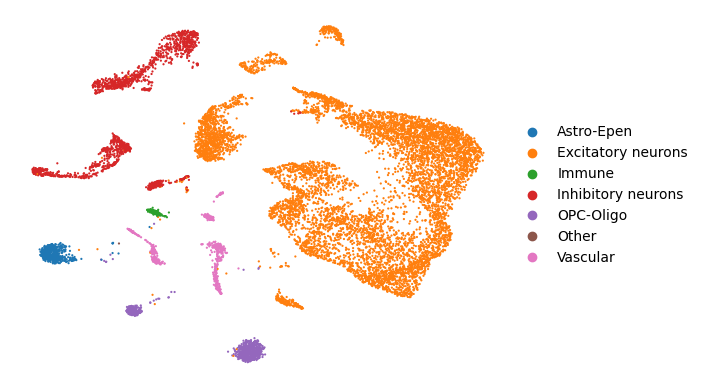

In [18]:
sc.pl.umap(adata, color='broad_cell_type', title='', frameon=False)

INFO

We have the overall gene expression for each cell.

*-> What to do with that data?*
One thing to do is to **group the cells together by gene expression** (microglia have different gene expressions than neurons, astrocytes, etc., as different proteins have different structures)
*-> Can we group cells together by similar gene expression patterns?*
Yes. The above graph does something similar.

**Clustering** is working out which cells are close together in a space in order to find genes with similar expression patterns. After clustering, each cell has a label with which cluster it is in, and the cluster labels identify which cells have similar expression patterns. This data set is very high dimensional.

**The above graph is a visualization of clustering.**

It's very hard to vsiualize single-cell data in 2d. UMAP is an algorithm that takes this form of data and tries to represent it in 2d such that cells with similar expression patterns are close together and cells with different expression patterns are far apart.

LIANA typically uses log1p-transformed counts matrix, which is...

To look at what's going on in cells, one can look at changes in protein expression, which is difficult so it's easier to look at levels of RNA as they translate into proteins.

microglia changes behavior by making proteins (by making RNA). By looking at RNA sequencing data, we can look at which genes are being expressed.

The data we are using in the actual project (not the toy data in this tutorial) is from the cells we want to measure the expression in, with the cells put in a machine that extracts all of the RNA and attaches a cell indictor barcode to the RNA molecules. You can then see the distribution of RNA molecules per cell (single cell) and in the brain in general. The single cell data is what we are using for the project (distribution of RNA on a single-cell level).

Our data will be a big matrix of A x B, A being cells (each column a cell), and B being genes (each row a gene), and the matrix shows how much of a certain gene is in a particular cell (which one is r/c is arbitrary right now).

In [19]:
adata.raw.X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 29964877 stored elements and shape (11910, 28117)>

In [20]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [21]:
# import liana's rank_aggregate
from liana.mt import rank_aggregate

In [22]:
rank_aggregate.__call__

<bound method AggregateClass.__call__ of <liana.method.sc._rank_aggregate.AggregateClass object at 0x0000010DCE5818B0>>

In [23]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


In [24]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

switched resource to mouseresource as toy data was human genes

In [25]:
# run cellphonedb
cellphonedb(adata,
            groupby='broad_cell_type',
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus', 
            expr_prop=0.1,
            verbose=True, key_added='cpdb_res')

Using resource `mouseconsensus`.
Using `.raw`!
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\legacy_api_wrap\__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2516 features of mat are empty, they will be removed.
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\_pipe_utils\_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\_pipe_utils\_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
The following cell identities were excluded: Other
0.10 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 11909 samples and 1411 features


100%|██████████| 1000/1000 [00:21<00:00, 45.73it/s]


In [26]:
# by default, liana's output is saved in place:
adata.uns['cpdb_res'].head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
1296,Nrxn1,Nrxn1,4.531085,0.992537,Nlgn1,Nlgn1,3.698021,0.998665,Astro-Epen,Excitatory neurons,4.114553,0.0
271,Nlgn1,Nlgn1,3.698021,0.998665,Nrxn1,Nrxn1,4.531085,0.992537,Excitatory neurons,Astro-Epen,4.114553,0.0
40,Nlgn1,Nlgn1,3.447225,0.996269,Nrxn1,Nrxn1,4.531085,0.992537,Astro-Epen,Astro-Epen,3.989155,0.0
26,Nrxn1,Nrxn1,4.531085,0.992537,Nlgn1,Nlgn1,3.447225,0.996269,Astro-Epen,Astro-Epen,3.989155,0.0
1544,Nlgn1,Nlgn1,3.698021,0.998665,Nrxn1,Nrxn1,3.896535,1.000000,Excitatory neurons,Excitatory neurons,3.797278,0.0


Dotplot

In [27]:
import matplotlib.pyplot as plt

In [ ]:
# li.pl.dotplot(adata = adata,
#               colour='lr_means',
#               size='cellphone_pvals',
#               inverse_size=True, # we inverse sign since we want small p-values to have large sizes
#               source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
#               target_labels=['CD34+', 'CD56+ NK'],
#               figure_size=(8, 7),
#               # finally, since cpdbv2 suggests using a filter to FPs
#               # we filter the pvals column to <= 0.05
#               filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
#               uns_key='cpdb_res' # uns_key to use, default is 'liana_res'
#              )

In [28]:
# This will show you exactly what columns were calculated
print(adata.uns['cpdb_res'].columns)

Index(['ligand', 'ligand_complex', 'ligand_means', 'ligand_props', 'receptor',
       'receptor_complex', 'receptor_means', 'receptor_props', 'source',
       'target', 'lr_means', 'cellphone_pvals'],
      dtype='object')


In [29]:
top_df = adata.uns['cpdb_res'].sort_values('lr_means', ascending=False).head(20)

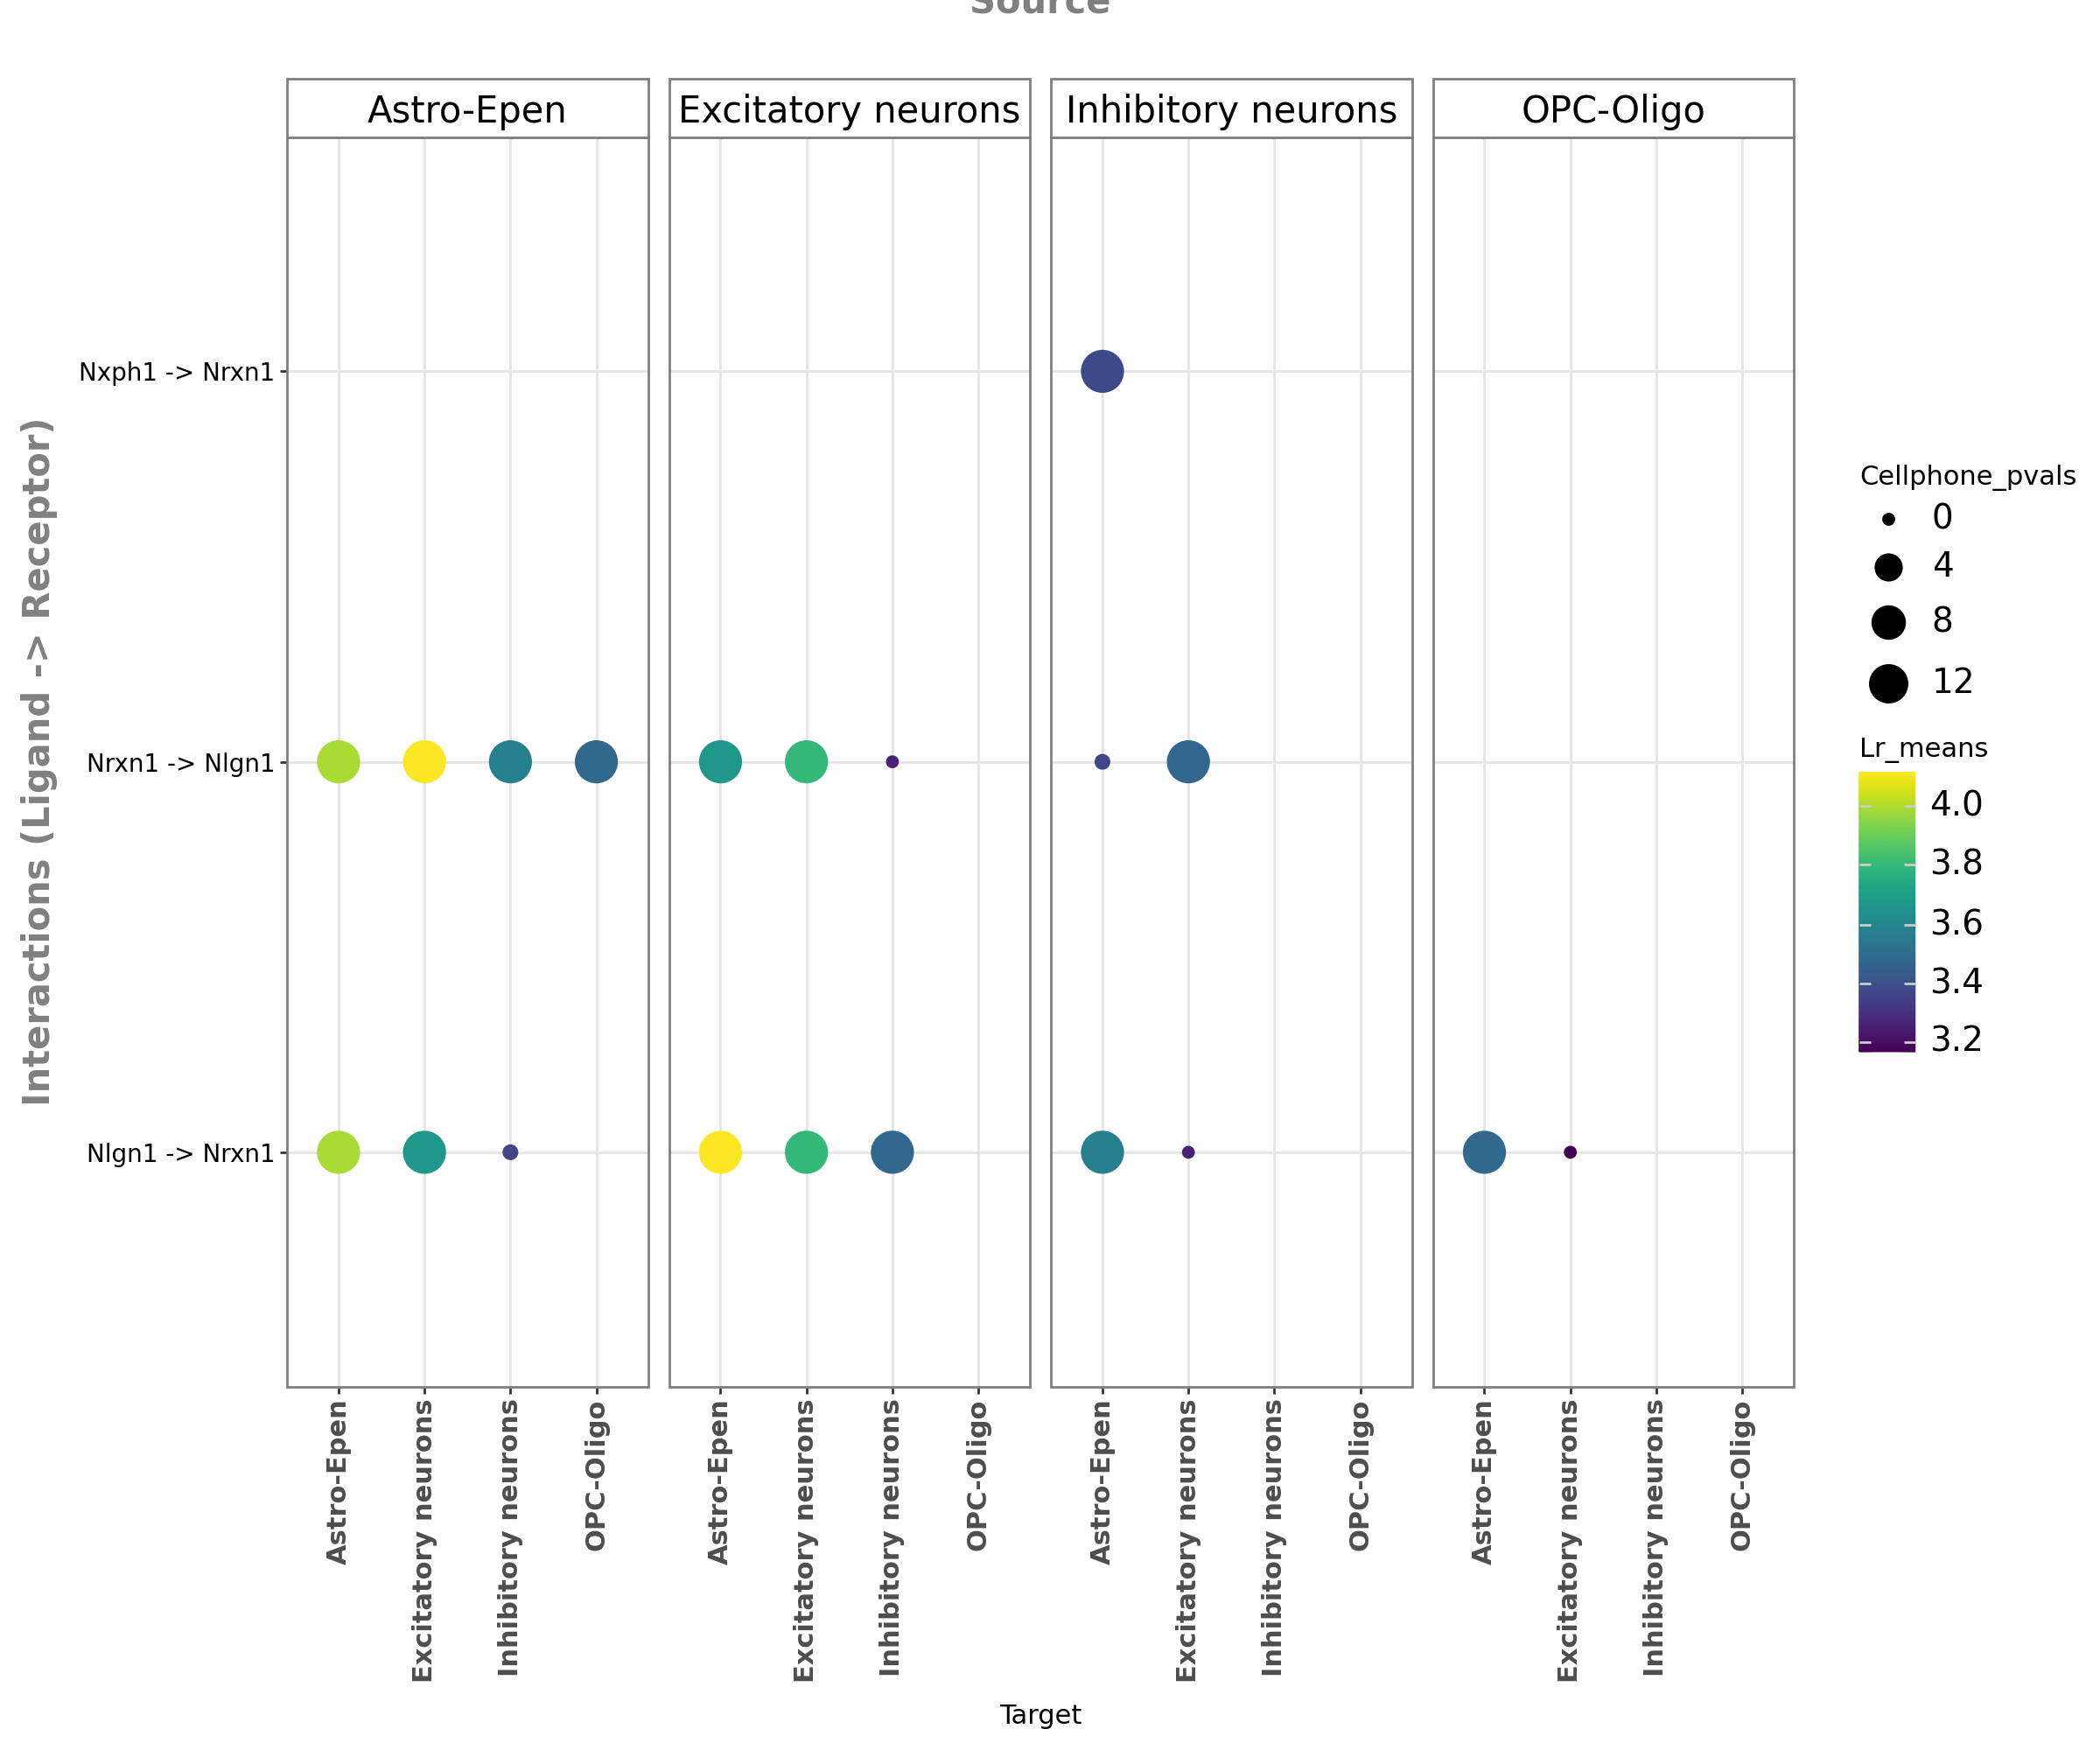

In [30]:
li.pl.dotplot(liana_res = top_df,
              colour = 'lr_means',
              size = 'cellphone_pvals',
              inverse_size = True,
              figure_size = (12, 10)
             )


In [ ]:
# Run this once to tell LIANA that 'cpdb_res' is the main result
# adata.uns['liana_res'] = adata.uns['cpdb_res']

original dot plot code and modifications of it do not work

In [ ]:
# li.pl.dotplot(adata = adata,
#               liana_res = adata.uns['cpdb_res'], 
#               colour = 'lr_means',
#               size = 'cellphone_pvals',
#               inverse_size = True,
#               # Explicitly define these to prevent the 'None' error
#               ligand_complex = 'ligand_complex',
#               receptor_complex = 'receptor_complex',
#               top_n = 20, 
#               figure_size = (10, 8)
#              )

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\plotting\_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


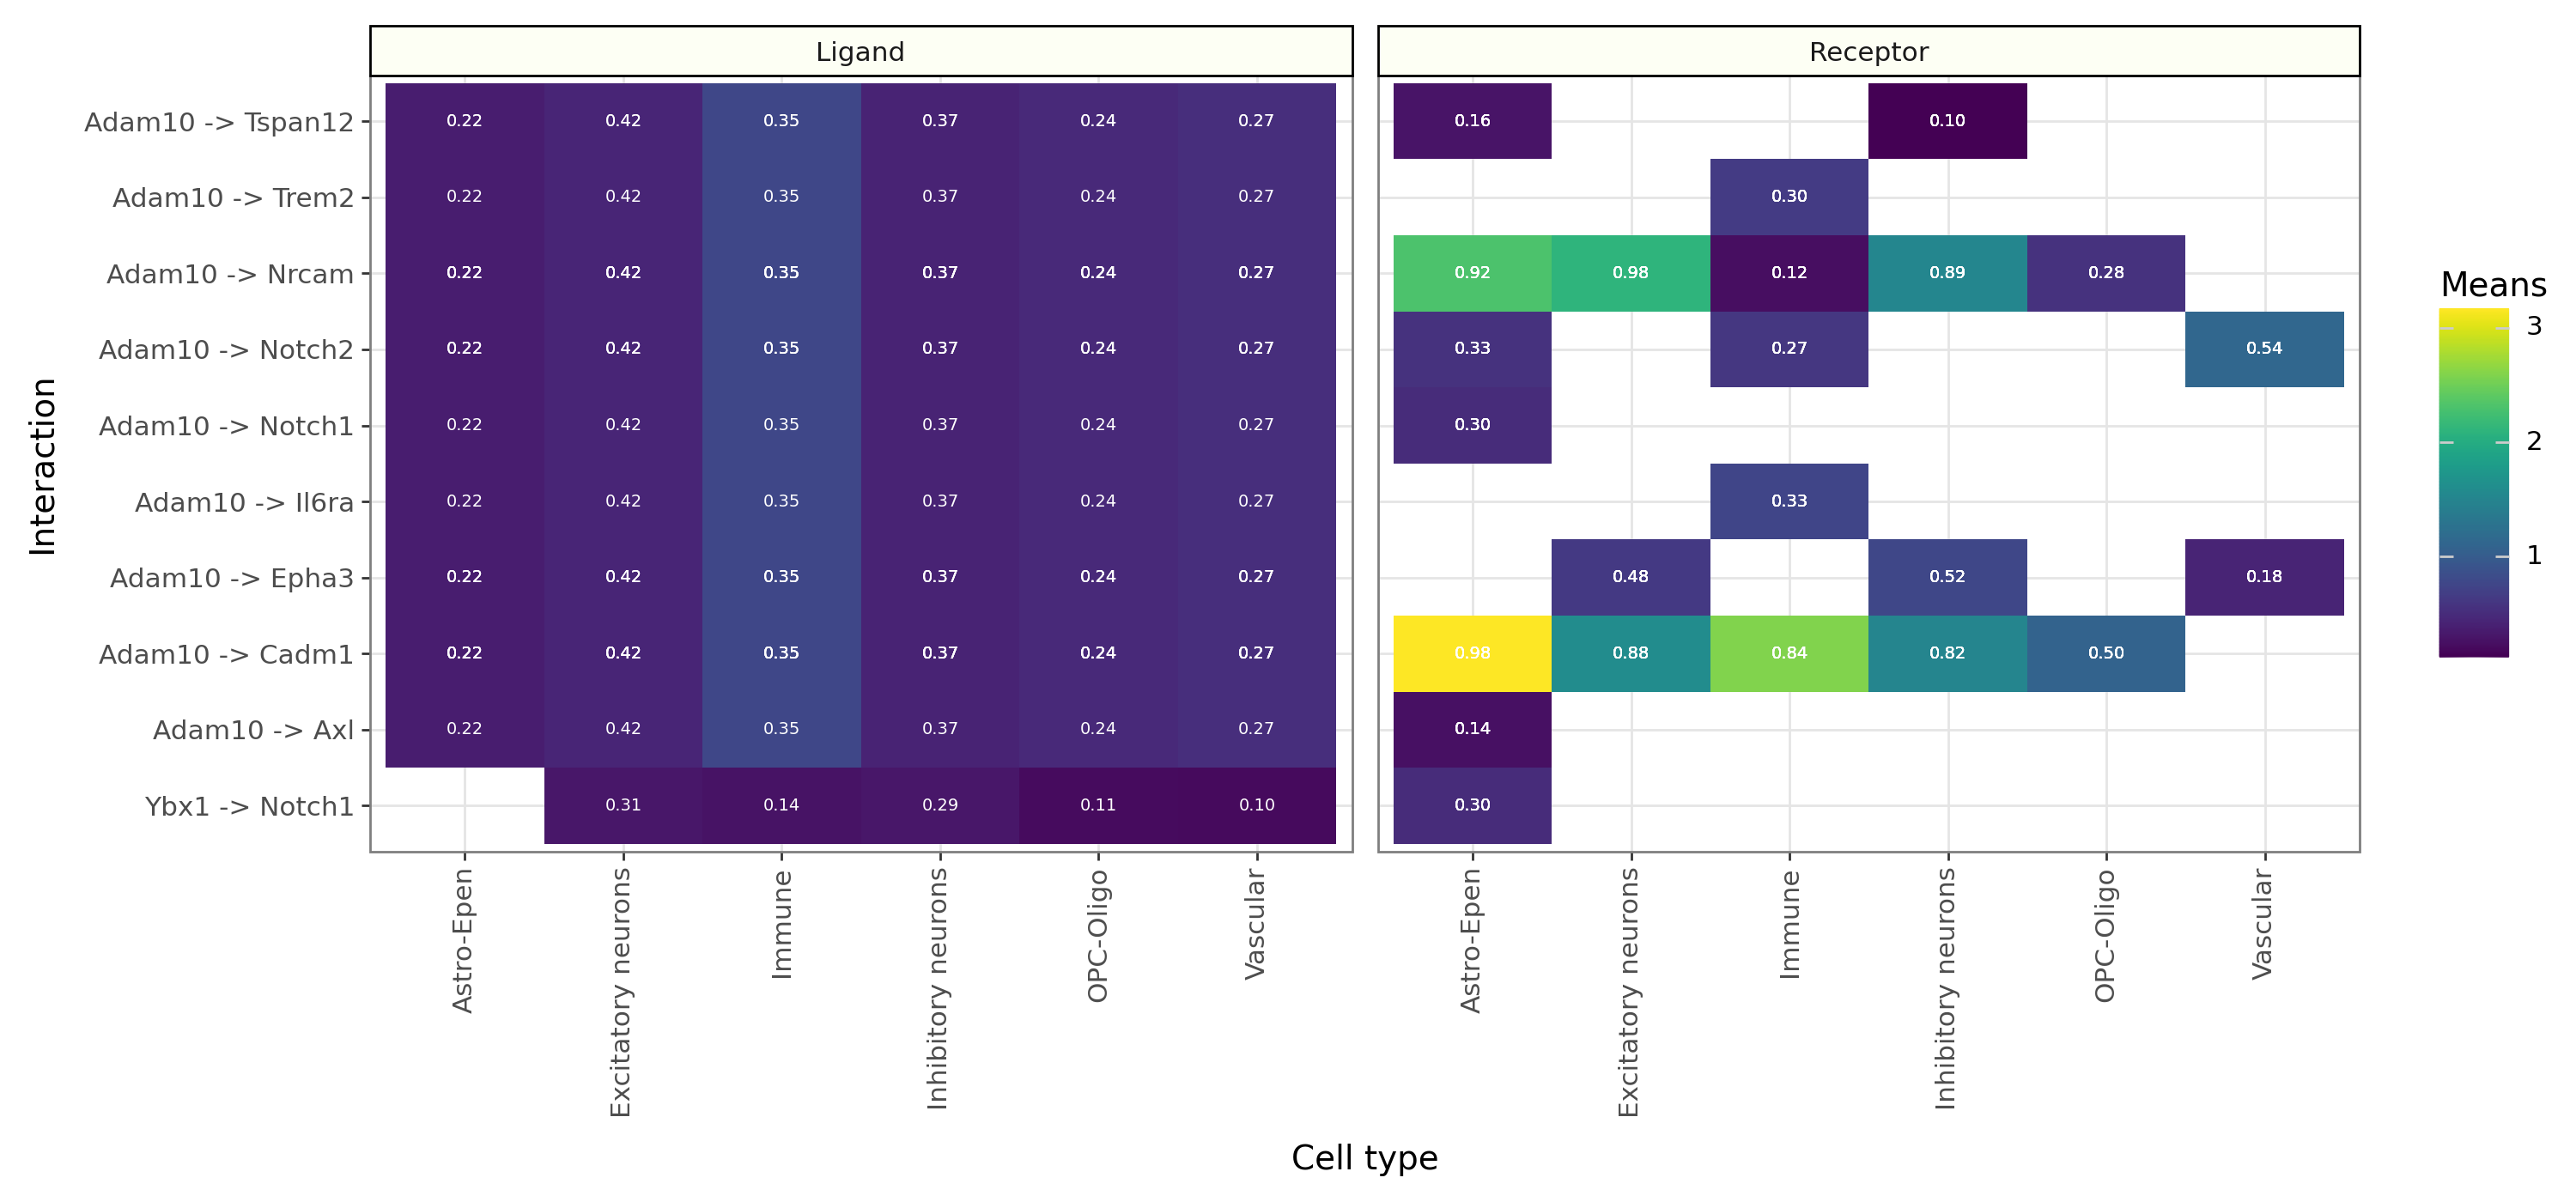

In [31]:
my_plot = li.pl.tileplot(adata = adata,
                         # NOTE: fill & label need to exist for both
                         # ligand_ and receptor_ columns
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=10,
                         orderby='cellphone_pvals',
                         orderby_ascending=True,
                        #  source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                        #  target_labels=['CD34+', 'CD56+ NK'],
                         uns_key='cpdb_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(15, 7),
                         label_size=7
                         )
my_plot

INFO

Ligand in this case acts as a communication molecule that is emitted, which is detected by the receptors.
Look at ligand-producing gene expression and same for receptor, you could see (for example) that certain types of cells might express certain ligands and some might express certain receptors. If we know cell type 1 expresses a gene associated with a particular ligand and cell type 2 with a particular receptor, and that ligand-receptor pair is one we know to communicate, then we know that those cells might be communicating with one another.

We want to look at communication changes in Alzheimer's mice eventually.

In [32]:
# Run rank_aggregate
li.mt.rank_aggregate(adata,
                     groupby='broad_cell_type',
                     resource_name='mouseconsensus',
                     expr_prop=0.1,
                     verbose=True)

Using resource `mouseconsensus`.
Using `.raw`!
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\legacy_api_wrap\__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2516 features of mat are empty, they will be removed.
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\_pipe_utils\_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\_pipe_utils\_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
The following cell identities were excluded: Other
0.10 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 11909 samples and 1411 features


c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\sc\_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\sc\_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\sc\_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:19<00:00, 50.82it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [33]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\plotting\_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


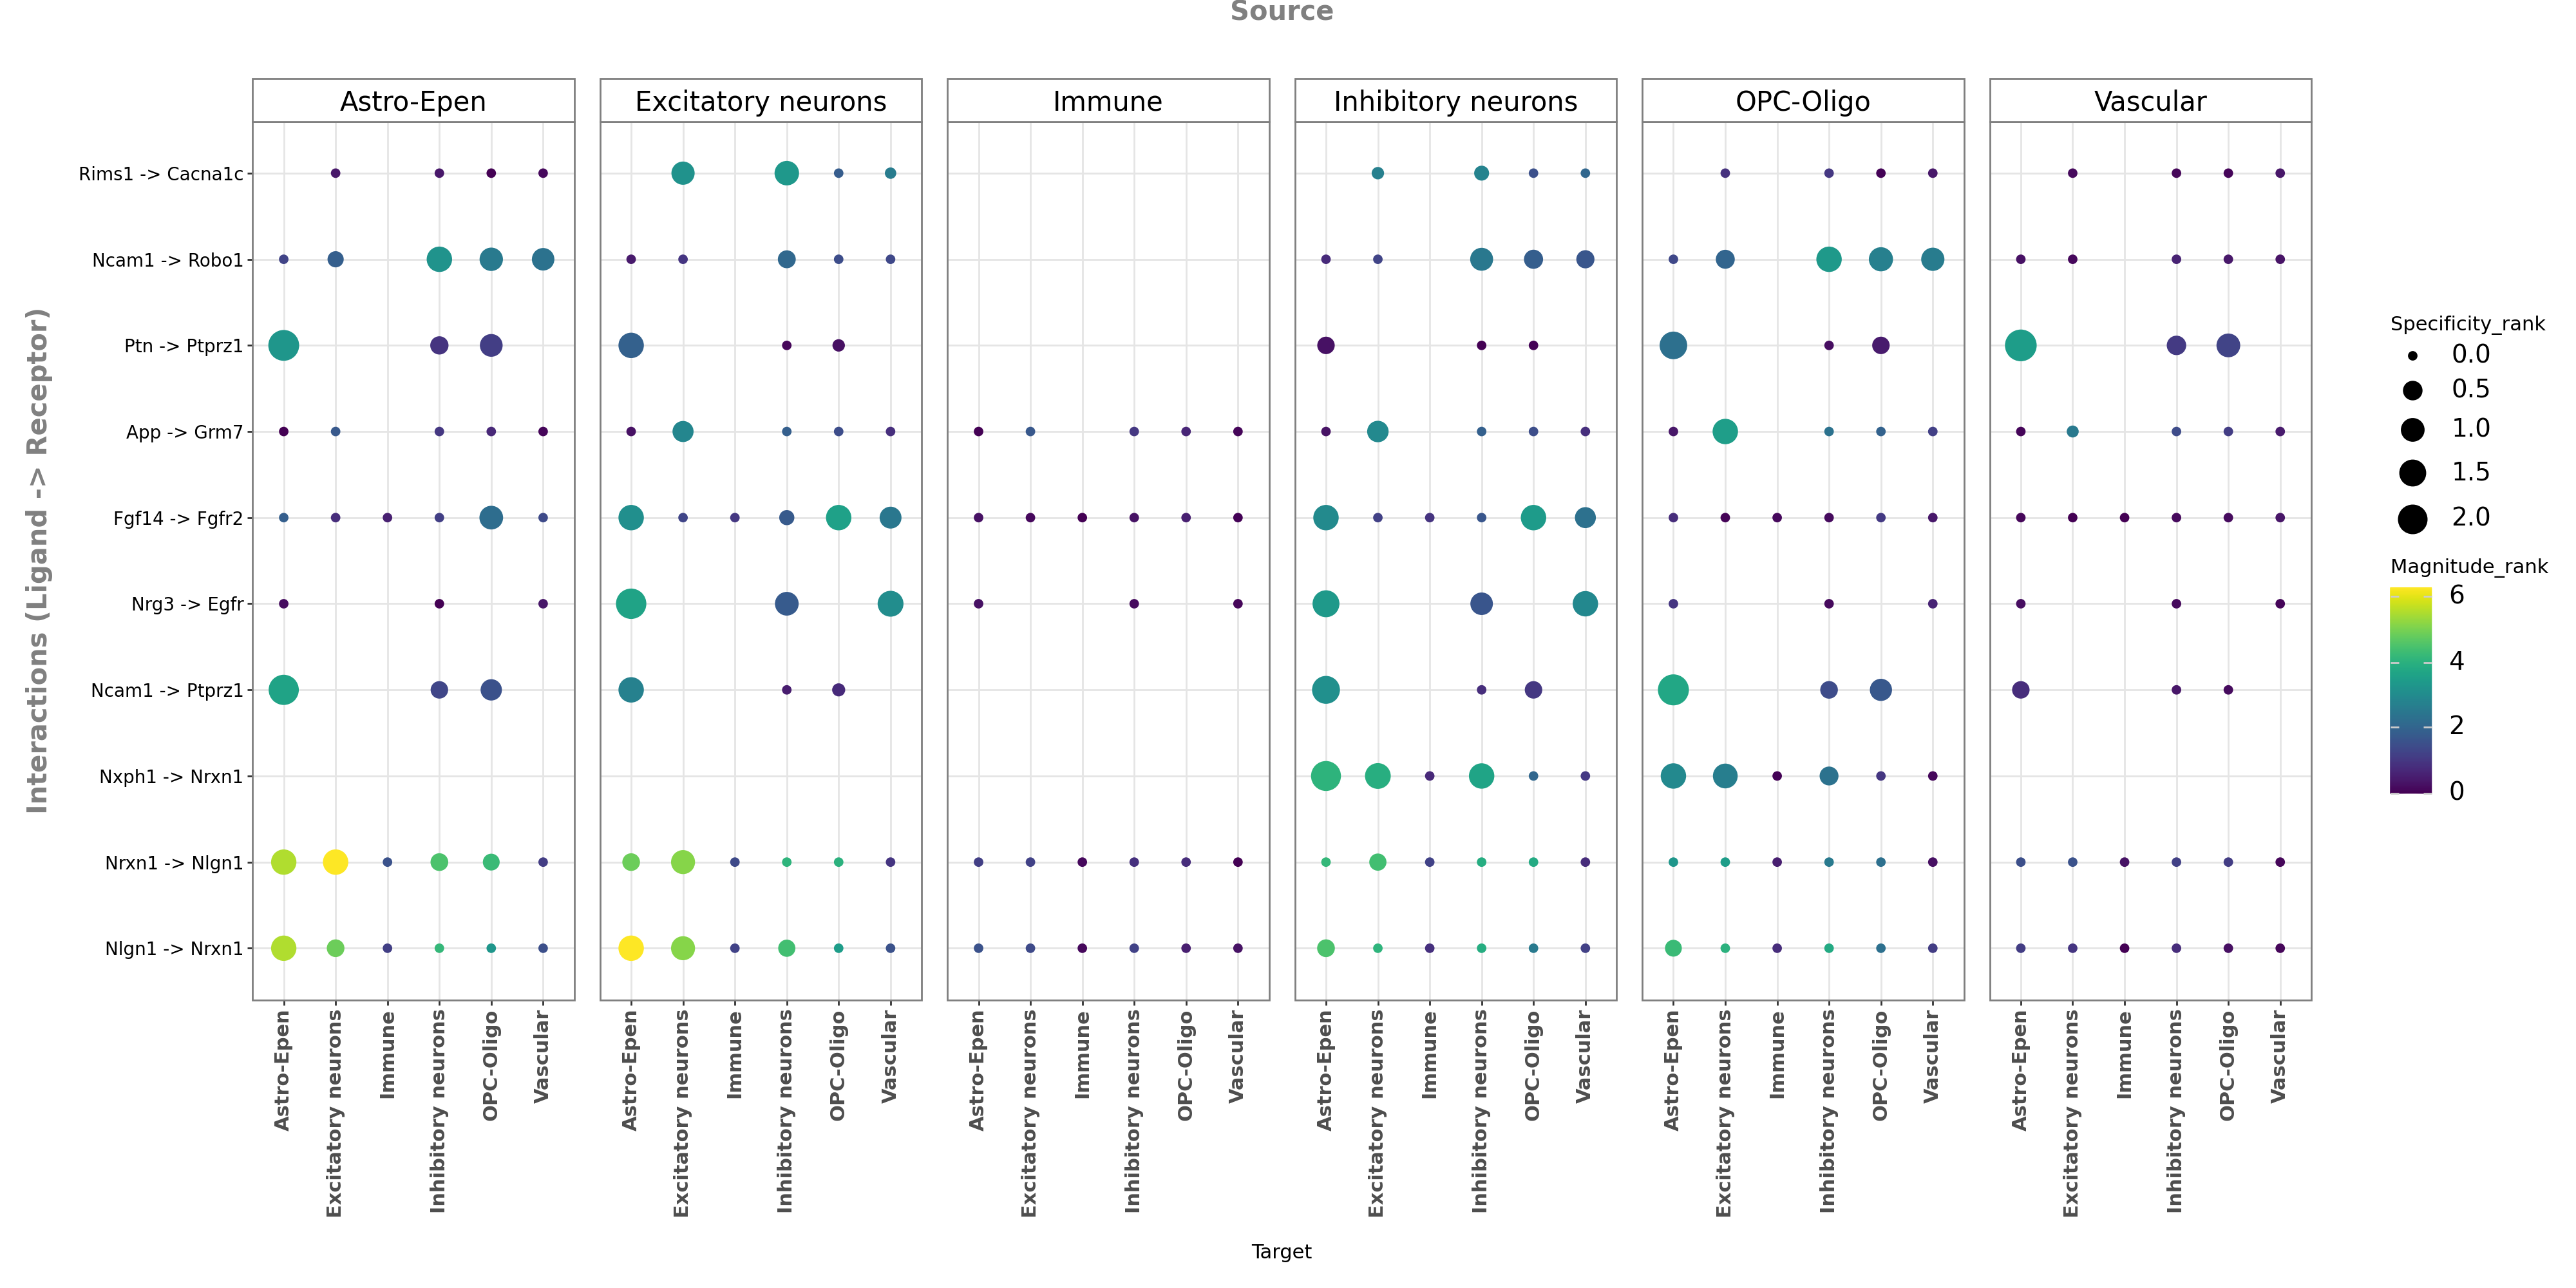

In [34]:
li.pl.dotplot(adata = adata,
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=True,
            #   source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
            #   target_labels=['CD34+', 'CD56+ NK'],
              top_n=10,
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(20, 10)
             )

In [ ]:
# my_plot = li.pl.dotplot(adata = adata,
#                         colour='magnitude_rank',
#                         inverse_colour=True,
#                         size='specificity_rank',
#                         inverse_size=True,
#                         # source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
#                         # target_labels=['CD34+', 'CD56+ NK'],
#                         filter_fun=lambda x: x['specificity_rank'] <= 0.01,
#                         figure_size=(20,10),
#                         top_n=30
#                        )
# my_plot

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\plotting\_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


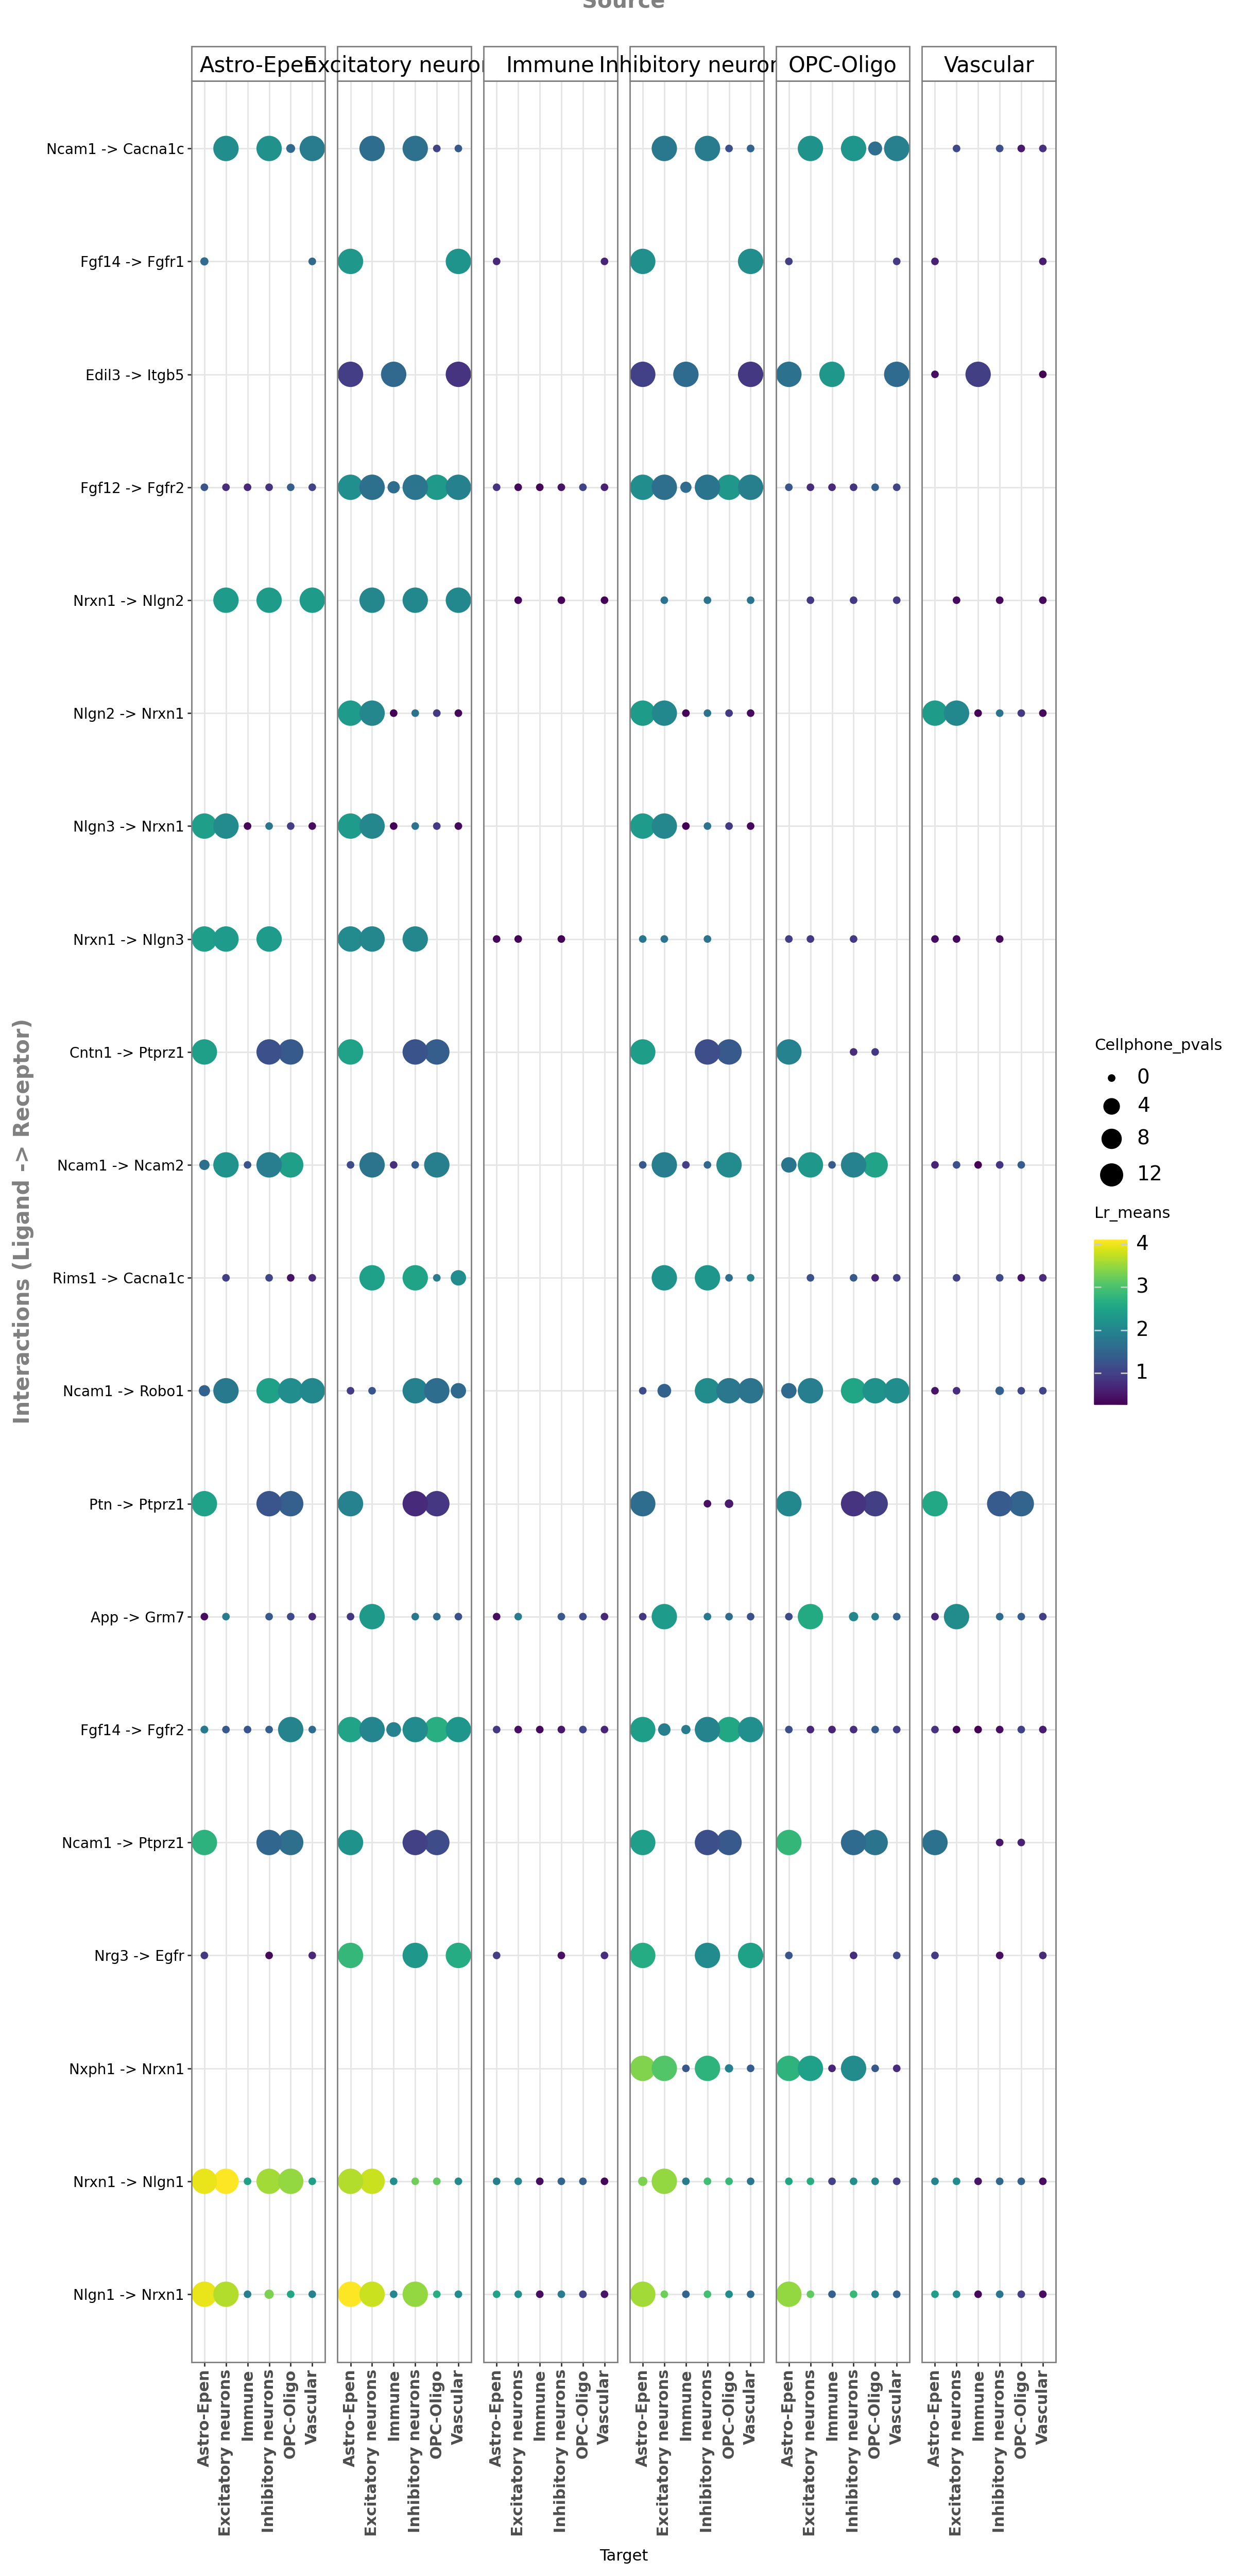

In [36]:
my_plot = li.pl.dotplot(adata = adata,
                        uns_key = 'cpdb_res',
                        colour = 'lr_means',
                        size = 'cellphone_pvals',
                        inverse_size = True, # High significance (low p-val) = Large dot
                        
                        # FIX: Tell LIANA how to find the "top" 20
                        orderby = 'lr_means', 
                        orderby_ascending = False, # Largest means at the top
                        
                        filter_fun = lambda x: x['cellphone_pvals'] <= 0.05,
                        top_n = 20,
                        figure_size = (12, 25)
                       )

# To display in a notebook, you usually just call the object
my_plot

In [37]:
# we import plotnine
import plotnine as p9

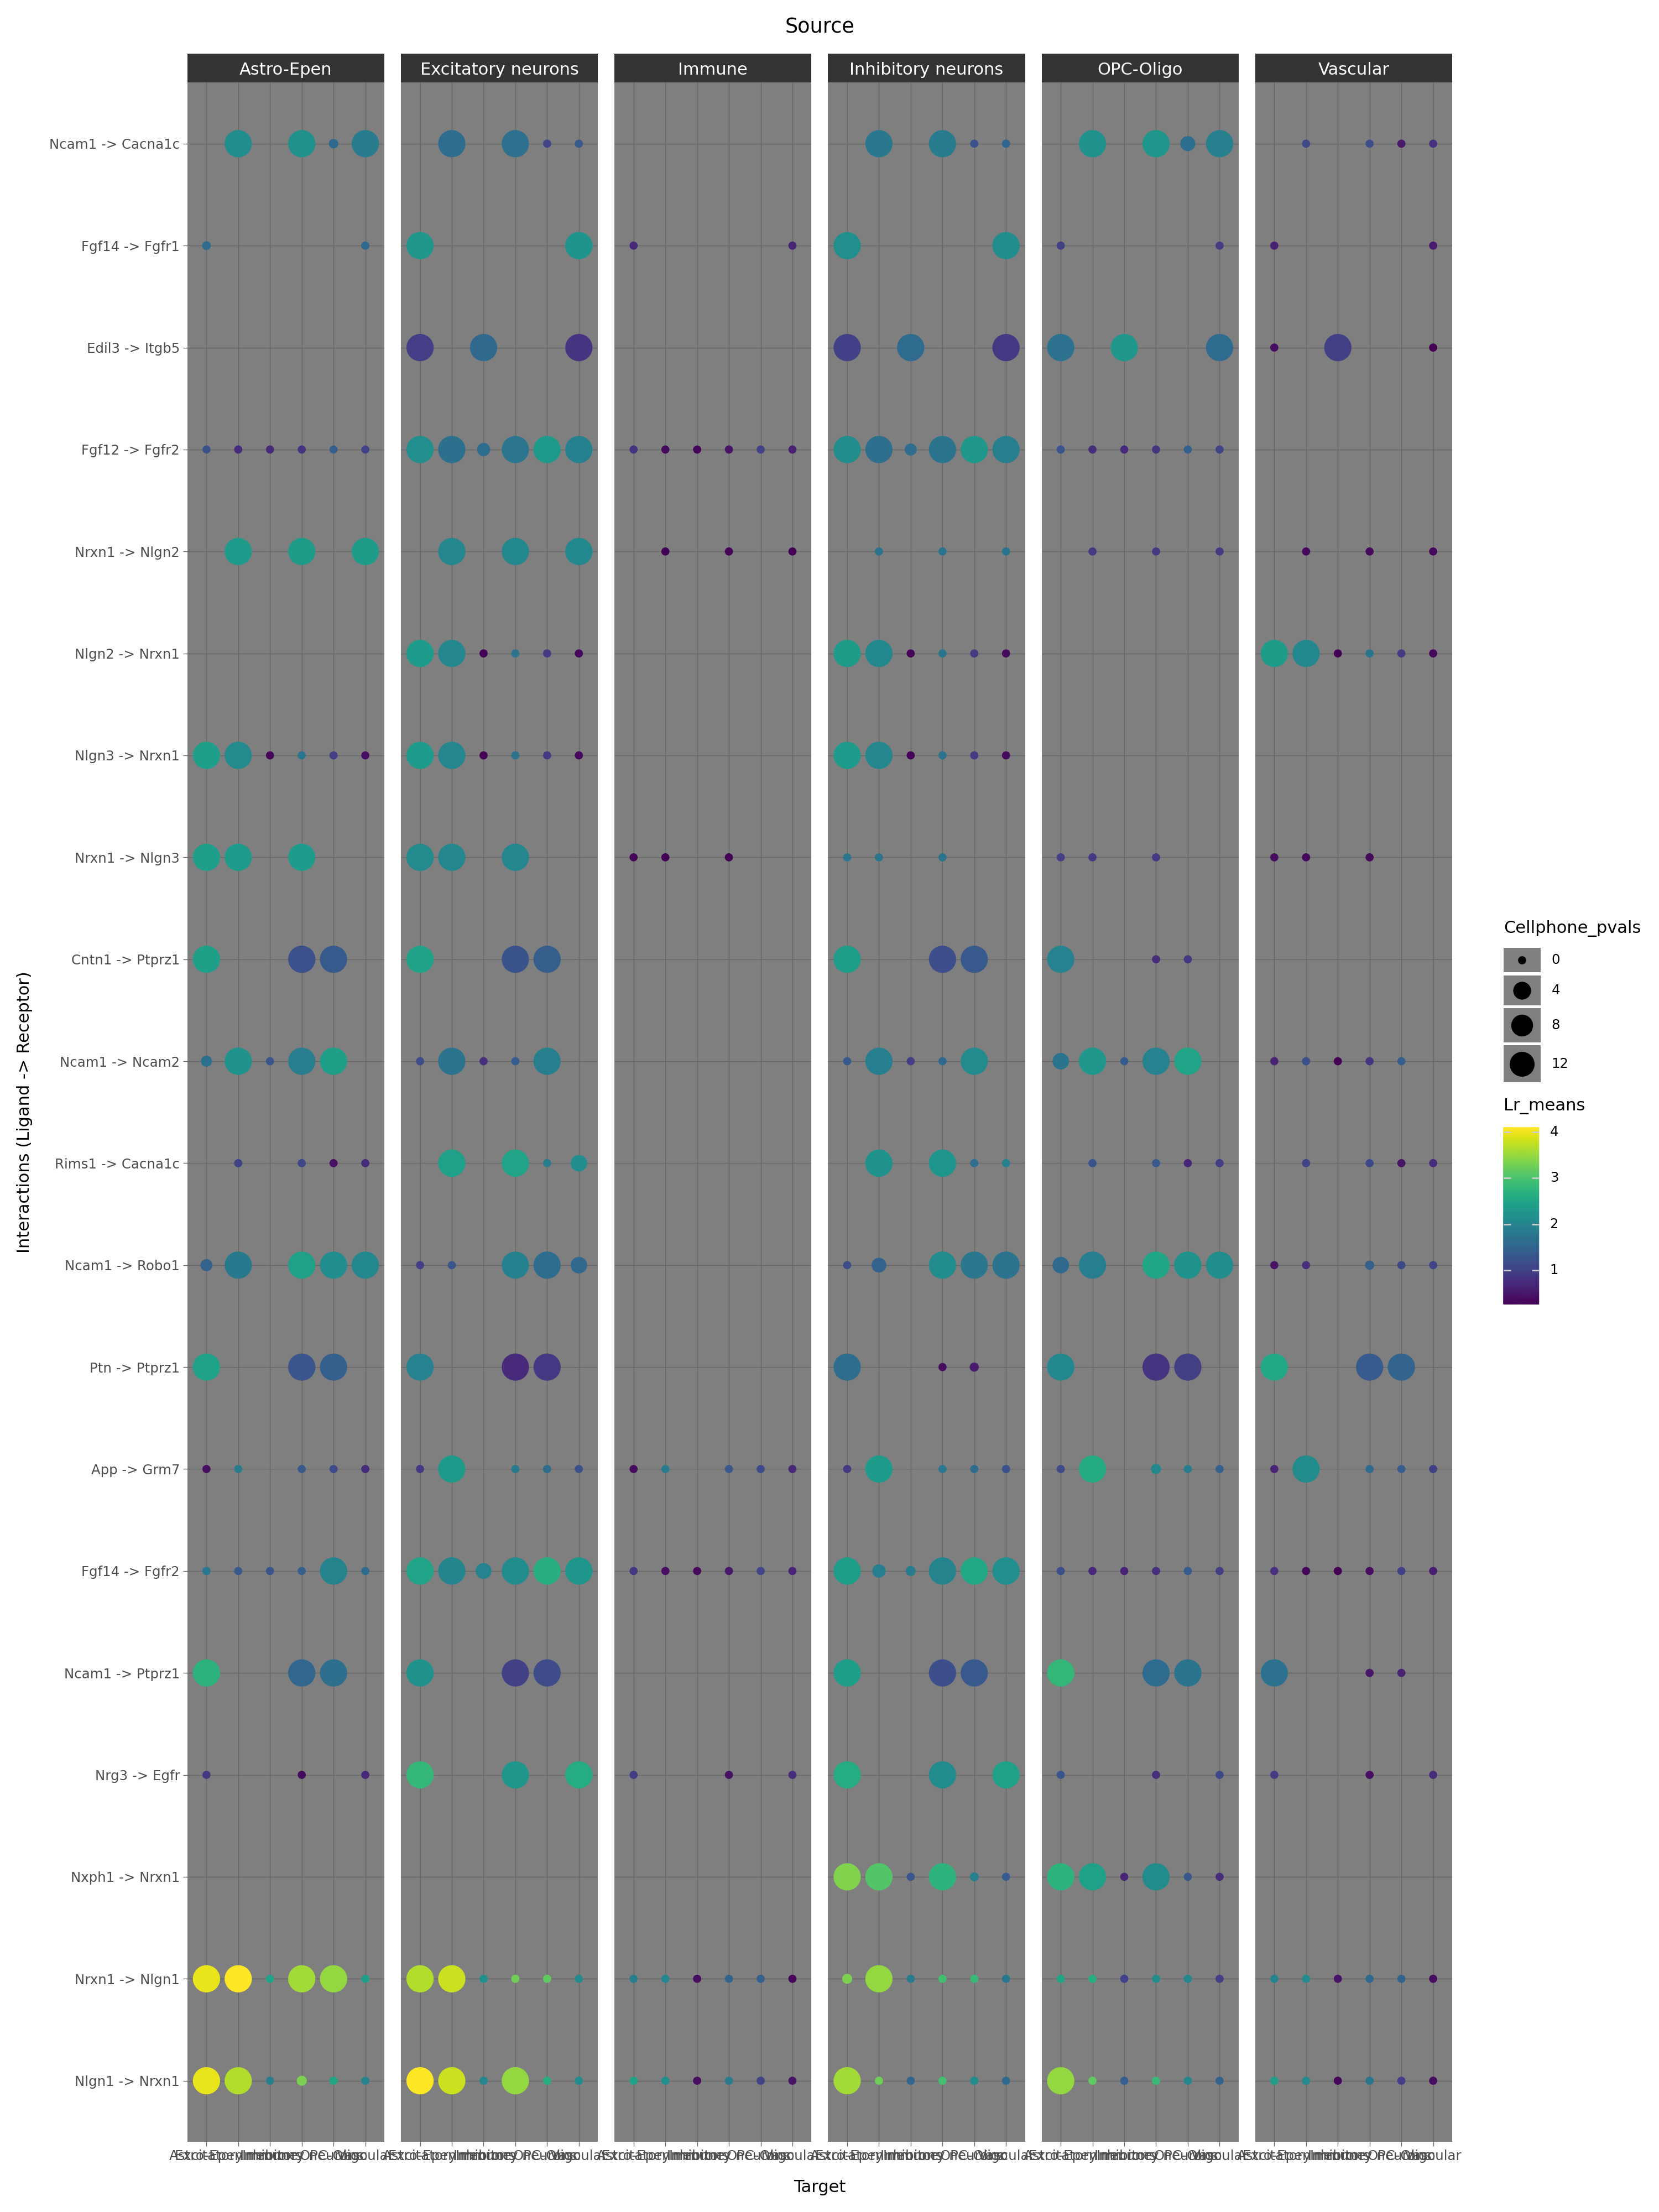

In [39]:
(my_plot +
 # change theme
 p9.theme_dark() +
 # modify theme
 p9.theme(
     # adjust facet size
     strip_text=p9.element_text(size=11),
     figure_size = (15, 20)
 )
)

<Axes: >

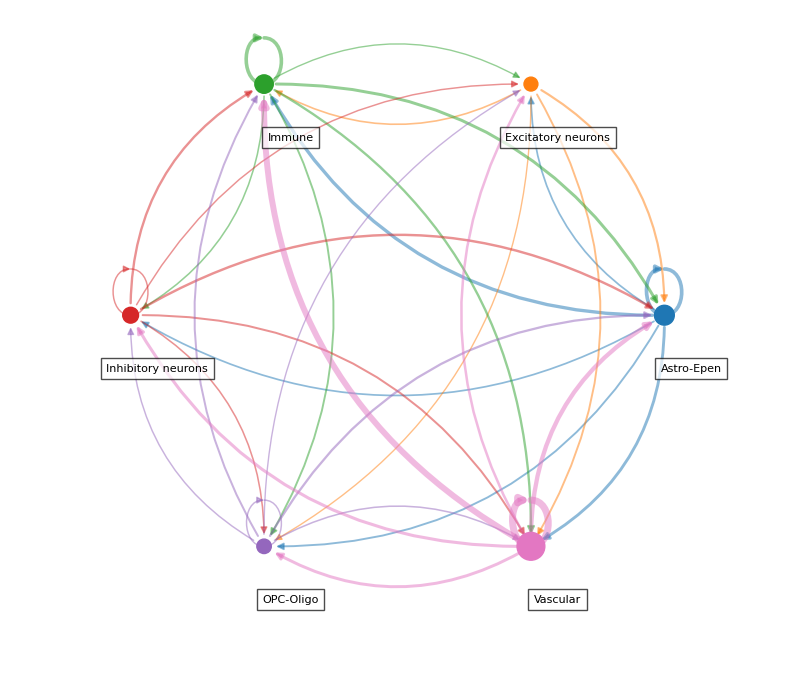

In [42]:
li.pl.circle_plot(adata,
                  groupby='broad_cell_type',
                  score_key='magnitude_rank',
                  inverse_score=True,
                #   source_labels='CD34+',
                  filter_fun=lambda x: x['specificity_rank'] <= 0.05,
                  pivot_mode='counts', # NOTE: this will simply count the interactions, 'mean' is also available
                  figure_size=(10, 10),
                  )

In [43]:
methods = [logfc, geometric_mean]
new_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)

In [46]:
new_rank_aggregate(adata,
                   groupby='broad_cell_type',
                   expr_prop=0.1,
                   verbose=True,
                   resource_name='mouseconsensus',
                   # Note that with this option, we don't perform permutations
                   # and hence we exclude the p-value for geometric_mean, as well as specificity_rank
                   n_perms=None,
                   use_raw=True,
                   )

Using resource `mouseconsensus`.
Using `.raw`!
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\legacy_api_wrap\__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2516 features of mat are empty, they will be removed.
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\_pipe_utils\_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\_pipe_utils\_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
The following cell identities were excluded: Other
0.10 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 11909 samples and 1411 features
Assuming that counts were `natural` log-normalized!


c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\sc\_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\sc\_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\method\sc\_liana_pipe.py:298: ImplicitModificationWarning: Setting element `.layers['normcounts']` of view, initializing view as actual.


Running log2FC
Running Geometric Mean


In [47]:
adata.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,lr_logfc,lr_gmeans,magnitude_rank
330,Astro-Epen,Excitatory neurons,Nrxn1,Nlgn1,1.123252,4.093416,0.000245
1154,Excitatory neurons,Astro-Epen,Nlgn1,Nrxn1,1.123252,4.093416,0.000245
139,Astro-Epen,Astro-Epen,Nrxn1,Nlgn1,0.560828,3.952173,0.000572
134,Astro-Epen,Astro-Epen,Nlgn1,Nrxn1,0.560828,3.952173,0.000572
1381,Excitatory neurons,Excitatory neurons,Nrxn1,Nlgn1,0.756847,3.795981,0.000900


Prior Knowledge

In [48]:
# !pip install omnipath
# !pip install decoupler

In [49]:
import omnipath as op
import decoupler as dc

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [50]:
li.resource.show_resources()

['baccin2019',
 'cellcall',
 'cellchatdb',
 'cellinker',
 'cellphonedb',
 'celltalkdb',
 'connectomedb2020',
 'consensus',
 'embrace',
 'guide2pharma',
 'hpmr',
 'icellnet',
 'italk',
 'kirouac2010',
 'lrdb',
 'mouseconsensus',
 'ramilowski2015']

In [51]:
resource = li.rs.select_resource('consensus')
resource.head()

,ligand,receptor
0,LGALS9,PTPRC
1,LGALS9,MET
2,LGALS9,CD44
3,LGALS9,LRP1
4,LGALS9,CD47


In [52]:
ligrec = op.interactions.import_intercell_network(
    interactions_params = {'license':'commercial'},
    transmitter_params = {'database':'CellChatDB'},
    receiver_params = {'database':'CellChatDB'},
    )
ligrec.head()

ligrec = ligrec.rename(columns={'genesymbol_intercell_source':'ligand', 'genesymbol_intercell_target':'receptor'})
ligrec = ligrec[['ligand', 'receptor', 'references'] + [col for col in ligrec.columns if col not in ['ligand', 'receptor', 'references']]]
ligrec.head()

,ligand,receptor,references,source,target,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,...,aspect_intercell_target,category_source_intercell_target,uniprot_intercell_target,entity_type_intercell_target,consensus_score_intercell_target,transmitter_intercell_target,receiver_intercell_target,secreted_intercell_target,plasma_membrane_transmembrane_intercell_target,plasma_membrane_peripheral_intercell_target
0,JAG2,NOTCH1,connectomeDB2020:11006133;ICELLNET:21352254;IC...,Q9Y219,P46531,True,True,True,True,False,...,functional,resource_specific,P46531,protein,22,False,True,False,True,False
1,DLL1,NOTCH1,ICELLNET:21685328;connectomeDB2020:9819428;con...,O00548,P46531,True,False,True,True,False,...,functional,resource_specific,P46531,protein,22,False,True,False,True,False
2,IGF1,IGF1R,ProtMapper:19258508;SPIKE:1852007;connectomeDB...,P05019,P08069,True,False,True,True,False,...,functional,resource_specific,P08069,protein,20,False,True,False,True,False
3,WNT1,NOTCH1,SPIKE:18495817;SPIKE_LC:18495817,P04628,P46531,True,False,True,True,False,...,functional,resource_specific,P46531,protein,22,False,True,False,True,False
4,JAG1,NOTCH1,SPIKE:18495817;ACSN:22330899;ICELLNET:18292500...,P78504,P46531,True,True,True,True,False,...,functional,resource_specific,P46531,protein,22,False,True,False,True,False


In [53]:
# let's say we are interested in zebrafish homologs of human genes
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_zebrafish_hcop_fifteen_column.txt.gz',
                                   columns=['human_symbol', 'zebrafish_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
# rename the columns to source and target, respectively for the original organism and the target organism
map_df = map_df.rename(columns={'human_symbol':'source', 'zebrafish_symbol':'target'})
map_df.tail()

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\resource\_orthology.py:204: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,source,target
132672,ZYG11B,zyg11
132673,ZYG11B,zyg11l
132674,ZYX,zyx
132676,ZZEF1,zzef1
132677,ZZZ3,zzz3


In [54]:
zfish = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # NOTE that we need to define the threshold of redundancies for the mapping
                                 # in this case, we would keep mappings as long as they don't map to more than 2 zebrafish genes
                                 one_to_many=3
                                 )

In [55]:
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
                                  columns=['human_symbol', 'mouse_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
# rename the columns to source and target, respectively for the original organism and the target organism
map_df = map_df.rename(columns={'human_symbol':'source', 'mouse_symbol':'target'})

# We will then translate
mouse = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # Here, we will be harsher and only keep mappings that don't map to more than 1 mouse gene
                                 one_to_many=1
                                 )
mouse

c:\Users\jasmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\liana\resource\_orthology.py:204: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,ligand,receptor
0,Lgals9,Ptprc
1,Lgals9,Met
2,Lgals9,Cd44
3,Lgals9,Lrp1
4,Lgals9,Cd47
...,...,...
4619,Bmp2,Actr2
4620,Bmp15,Actr2
4621,Csf1,Csf3r
4622,Il36g,Ifnar1


In [56]:
# load PROGENy pathways, we use decoupler as a proxy as it formats the data in a more convenient way
progeny = dc.op.progeny(top=2500)
progeny.head()

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40


In [58]:
# load full list of ligand-receptor pairs
lr_pairs = li.resource.select_resource('mouseconsensus')

In [59]:
# generate ligand-receptor geneset
lr_progeny = li.rs.generate_lr_geneset(lr_pairs, progeny, lr_sep="^")
lr_progeny.head()

,source,interaction,weight


In [60]:
diseases = op.requests.Annotations.get(
    resources = ['DisGeNet']
    )

In [61]:
diseases = diseases[['genesymbol', 'label', 'value']]
diseases = diseases.pivot_table(index='genesymbol',
                                columns='label', values='value',
                                aggfunc=lambda x: '; '.join(x)).reset_index()
diseases = diseases[['genesymbol', 'disease']]
diseases['disease'] = diseases['disease'].str.split('; ')
diseases = diseases.explode('disease')
lr_diseases = li.rs.generate_lr_geneset(lr_pairs, diseases, source='disease', target='genesymbol', weight=None, lr_sep="^")
lr_diseases.sort_values("interaction").head()

C:\Users\jasmi\AppData\Local\Temp\ipykernel_4852\3054253547.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


,disease,interaction
48,Thrombosis,F10^F3
66,Thrombus,F10^F3
105,Deep Vein Thrombosis,F7^F3
123,Disseminated Intravascular Coagulation,F7^F3
356,Venous Thrombosis,F7^F3


In [ ]:
ppis = op.interactions.OmniPath().get(genesymbols = True)
ppis.head()

12.5MB [00:00, 26.7MB/s]


,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,sources,references,curation_effort,n_sources,n_primary_sources,n_references,references_stripped
0,P0DP25,P48995,CALM3,TRPC1,True,False,True,True,False,True,TRIP,TRIP:11983166;TRIP:12601176;TRIP:11290752,3,1,1,3,11290752;11983166;12601176
1,P0DP23,P48995,CALM1,TRPC1,True,False,True,True,False,True,TRIP,TRIP:11983166;TRIP:12601176;TRIP:11290752,3,1,1,3,11290752;11983166;12601176
2,P0DP24,P48995,CALM2,TRPC1,True,False,True,True,False,True,TRIP,TRIP:11983166;TRIP:12601176;TRIP:11290752,3,1,1,3,11290752;11983166;12601176
3,Q03135,P48995,CAV1,TRPC1,True,True,False,True,True,False,TRIP;HPRD;HINT;IntAct;DIP;Lit-BM-17,IntAct:19897728;HPRD:12732636;TRIP:18430726;Li...,15,6,6,8,10980191;12732636;14551243;16822931;18430726;1...
4,P14416,P48995,DRD2,TRPC1,True,True,False,True,True,False,TRIP,TRIP:18261457,1,1,1,1,18261457


In [62]:
dc.op.collectri(organism='mouse', remove_complexes=False, license='academic', verbose=False).head()

,source,target,weight,resources,references,sign_decision
0,Myc,Tert,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,Spi1,Bglap3,1.0,ExTRI,10022617,default activation
2,Spi1,Bglap,1.0,ExTRI,10022617,default activation
3,Spi1,Bglap2,1.0,ExTRI,10022617,default activation
4,Smad3,Jun,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID


In [64]:
li.resource.get_metalinks_values(table_name='disease', column_name='disease')[0:5]

['Molybdenum cofactor deficiency',
 'Metastatic melanoma',
 'Schizophrenia',
 'Anoxia',
 'Colorectal cancer']

In [65]:
# Get the resource for a specific disease, e.g., 'Alzheimer Disease'
dis_res = li.rs.get_metalinks(disease='Alzheimer Disease')

# Look at the gene symbols in the resource
print(dis_res.head()) 

# Check if they are Title Case (Mouse-style)
# LIANA usually converts these on-the-fly when you run the actual analysis

Empty DataFrame
Columns: [hmdb, uniprot, gene_symbol, metabolite, mor, transport_direction, type, source]
Index: []


In [66]:
li.resource.get_metalinks(source=['Stich', 'CellPhoneDB', 'NeuronChat'],
                          tissue_location='Brain',
                          biospecimen_location='Cerebrospinal Fluid (CSF)',
                          disease='Schizophrenia',
                          ).head()

,hmdb,uniprot,gene_symbol,metabolite,mor,transport_direction,type,source
0,HMDB0000234,P10275,AR,Testosterone,-1,None,lr,CellPhoneDB
1,HMDB0000234,P10275,AR,Testosterone,0,None,lr,CellPhoneDB
2,HMDB0000234,P10275,AR,Testosterone,1,None,lr,CellPhoneDB
3,HMDB0000073,A5X5Y0,HTR3E,Dopamine,1,None,lr,CellPhoneDB
4,HMDB0000073,O95264,HTR3B,Dopamine,1,None,lr,CellPhoneDB


In [67]:
li.rs.describe_metalinks()

Schema of table: metabolites
Column ID: 0, Name: hmdb, Type: TEXT, Primary Key: 0
Column ID: 1, Name: metabolite, Type: TEXT, Primary Key: 0
Column ID: 2, Name: pubchem, Type: TEXT, Primary Key: 0
Column ID: 3, Name: metabolite_subclass, Type: TEXT, Primary Key: 0

No Foreign Keys.
----------------------------------------
Schema of table: proteins
Column ID: 0, Name: uniprot, Type: TEXT, Primary Key: 0
Column ID: 1, Name: gene_symbol, Type: TEXT, Primary Key: 0
Column ID: 2, Name: protein_type, Type: TEXT, Primary Key: 0

No Foreign Keys.
----------------------------------------
Schema of table: edges
Column ID: 0, Name: hmdb, Type: TEXT, Primary Key: 0
Column ID: 1, Name: uniprot, Type: TEXT, Primary Key: 0
Column ID: 2, Name: source, Type: TEXT, Primary Key: 0
Column ID: 3, Name: db_score, Type: REAL, Primary Key: 0
Column ID: 4, Name: experiment_score, Type: REAL, Primary Key: 0
Column ID: 5, Name: combined_score, Type: REAL, Primary Key: 0
Column ID: 6, Name: mor, Type: INTEGER, Pr